In [1]:
# ======================================
# Import Libraries
# ======================================
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from statsmodels.tsa.arima.model import ARIMA
import joblib

In [2]:
# ======================================
# Load Dataset
# ======================================

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
print(df.shape)

print(df.info())


(2640, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None


In [4]:
print(df.describe())

              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000           2640.000000       2640.000000   
mean   2020.000000     6.500000           9922.199621      10655.847348   
std       3.162877     3.452707           3935.950093       4260.600858   
min    2015.000000     1.000000             48.000000         50.000000   
25%    2017.000000     3.750000           7292.000000       7828.250000   
50%    2020.000000     6.500000           9857.000000      10546.500000   
75%    2023.000000     9.250000          12510.250000      13469.000000   
max    2025.000000    12.000000          25704.000000      28939.000000   

       Avg_Price_USD  Battery_Capacity_kWh     Range_km  CO2_Saved_tons  \
count    2640.000000           2640.000000  2640.000000     2640.000000   
mean    84907.340330             87.059470   500.257576      744.076989   
std     20123.258036             20.836265   120.868549      353.221224   
min     50003.700000    

In [5]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
categorical_columns = [
    "Region",
    "Model",
    "Source_Type"
]

for col in categorical_columns:
    df[col] = df[col].astype("category")

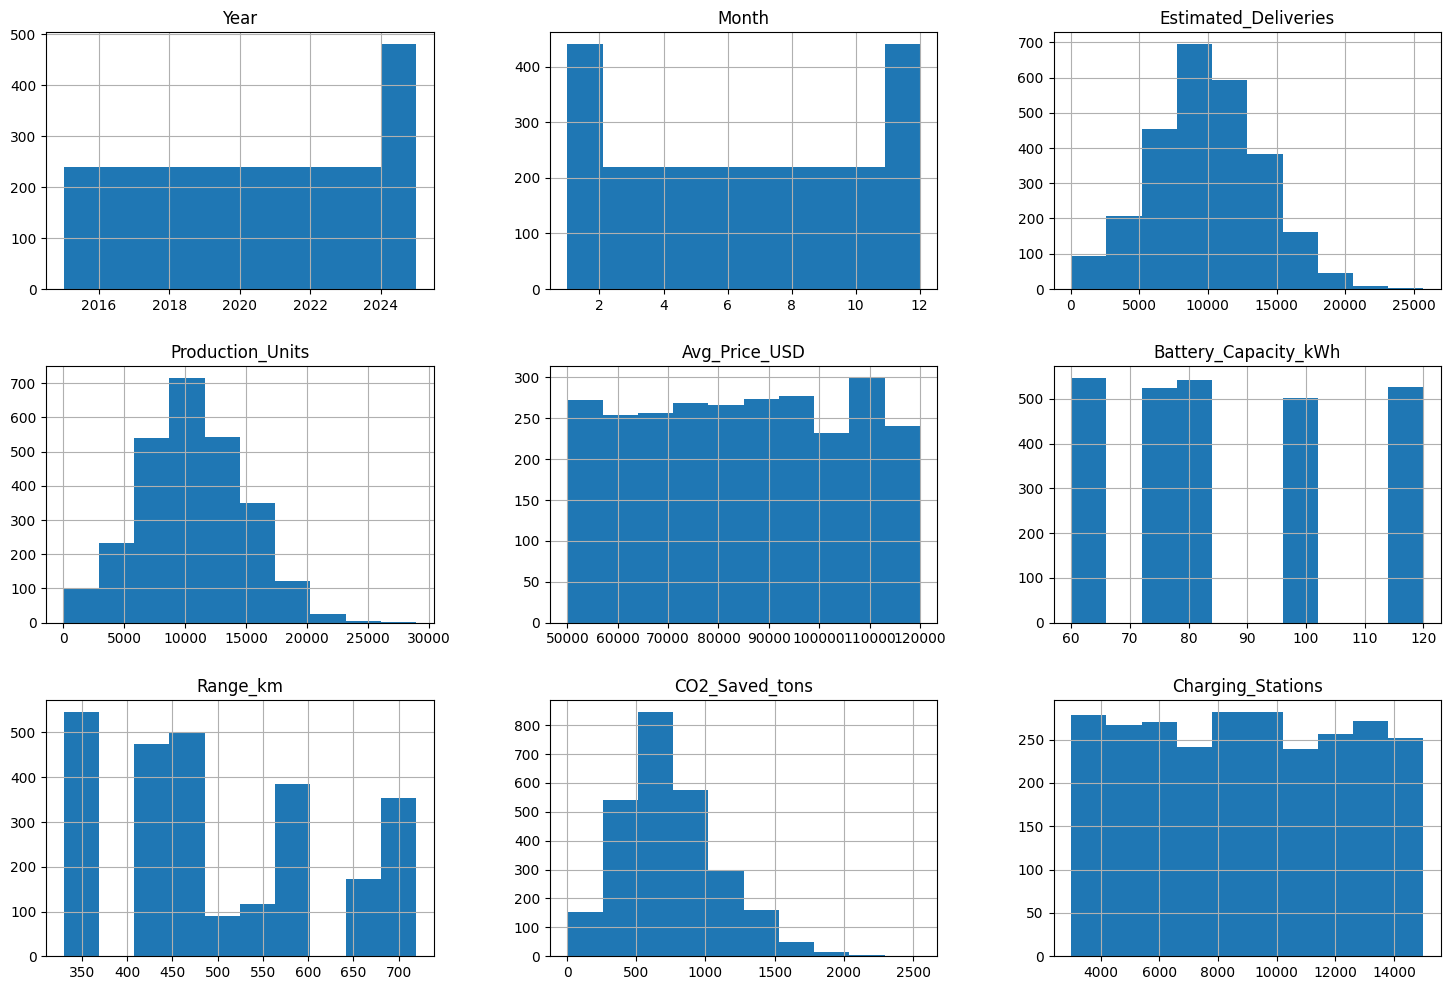

In [9]:
df.hist(figsize=(18,12))
plt.show()

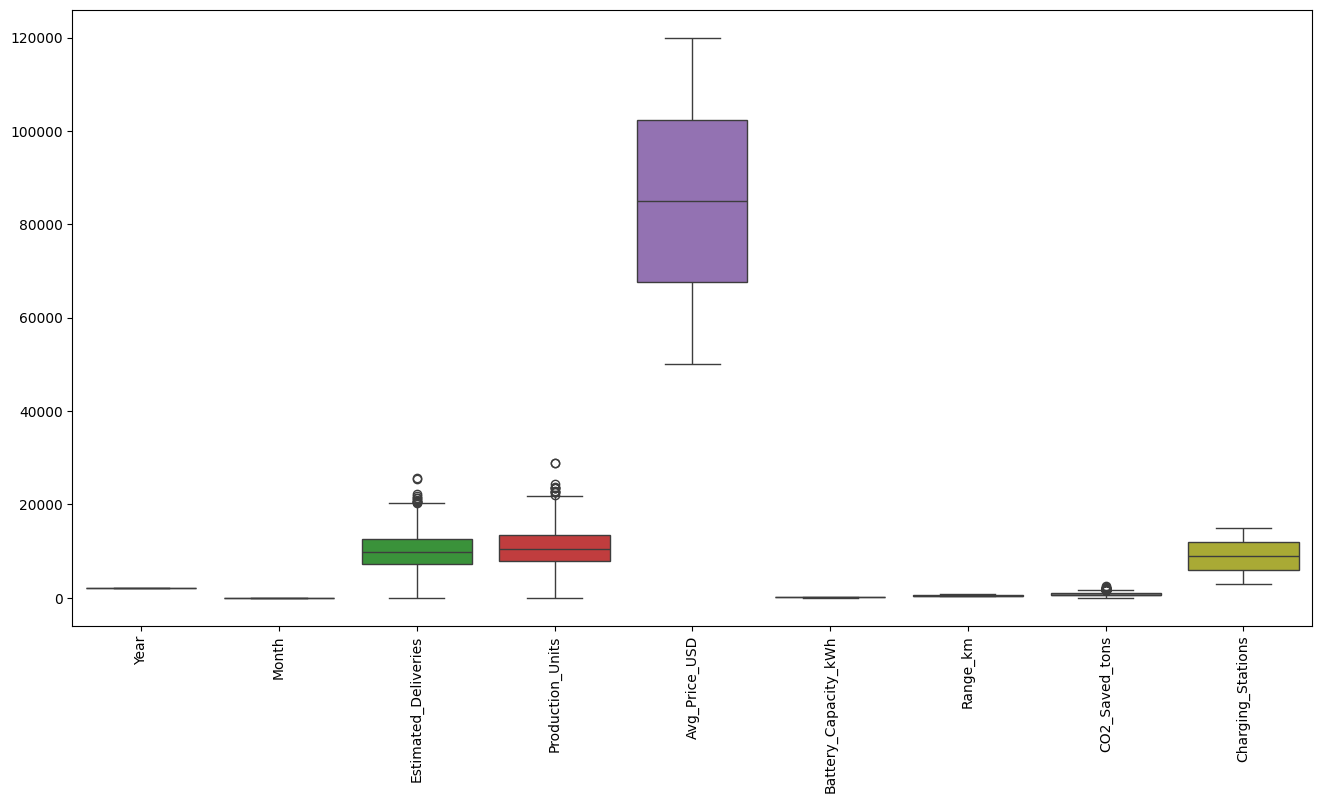

In [10]:
plt.figure(figsize=(16,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

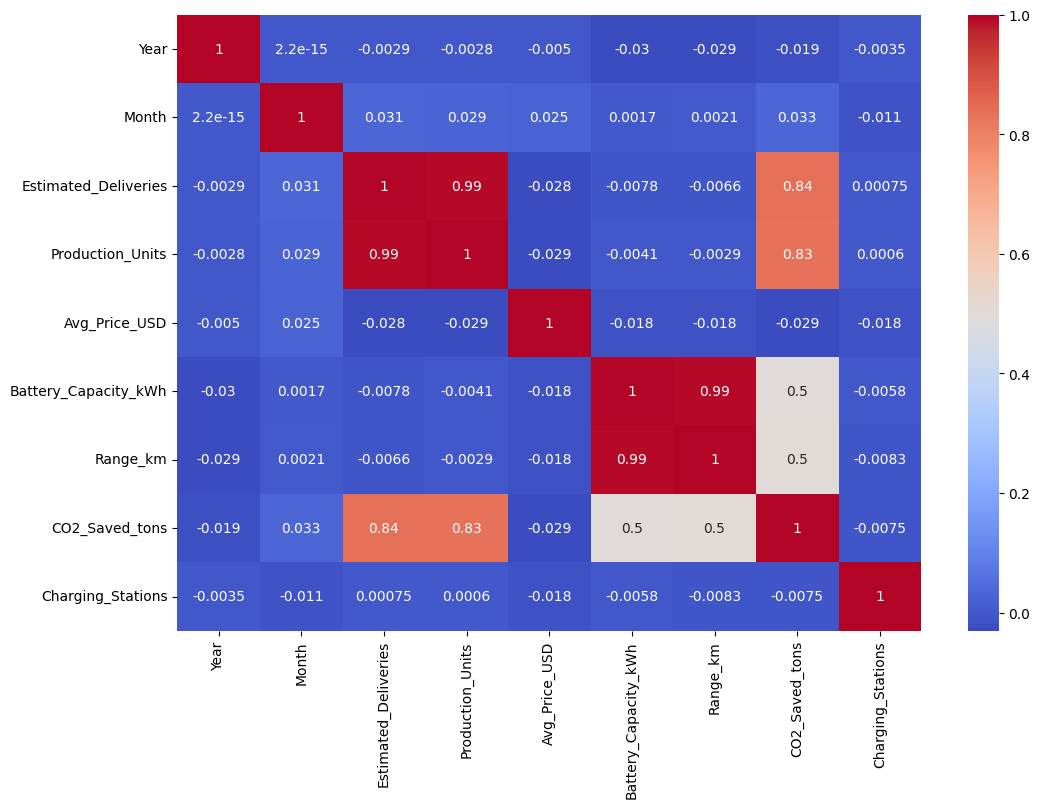

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

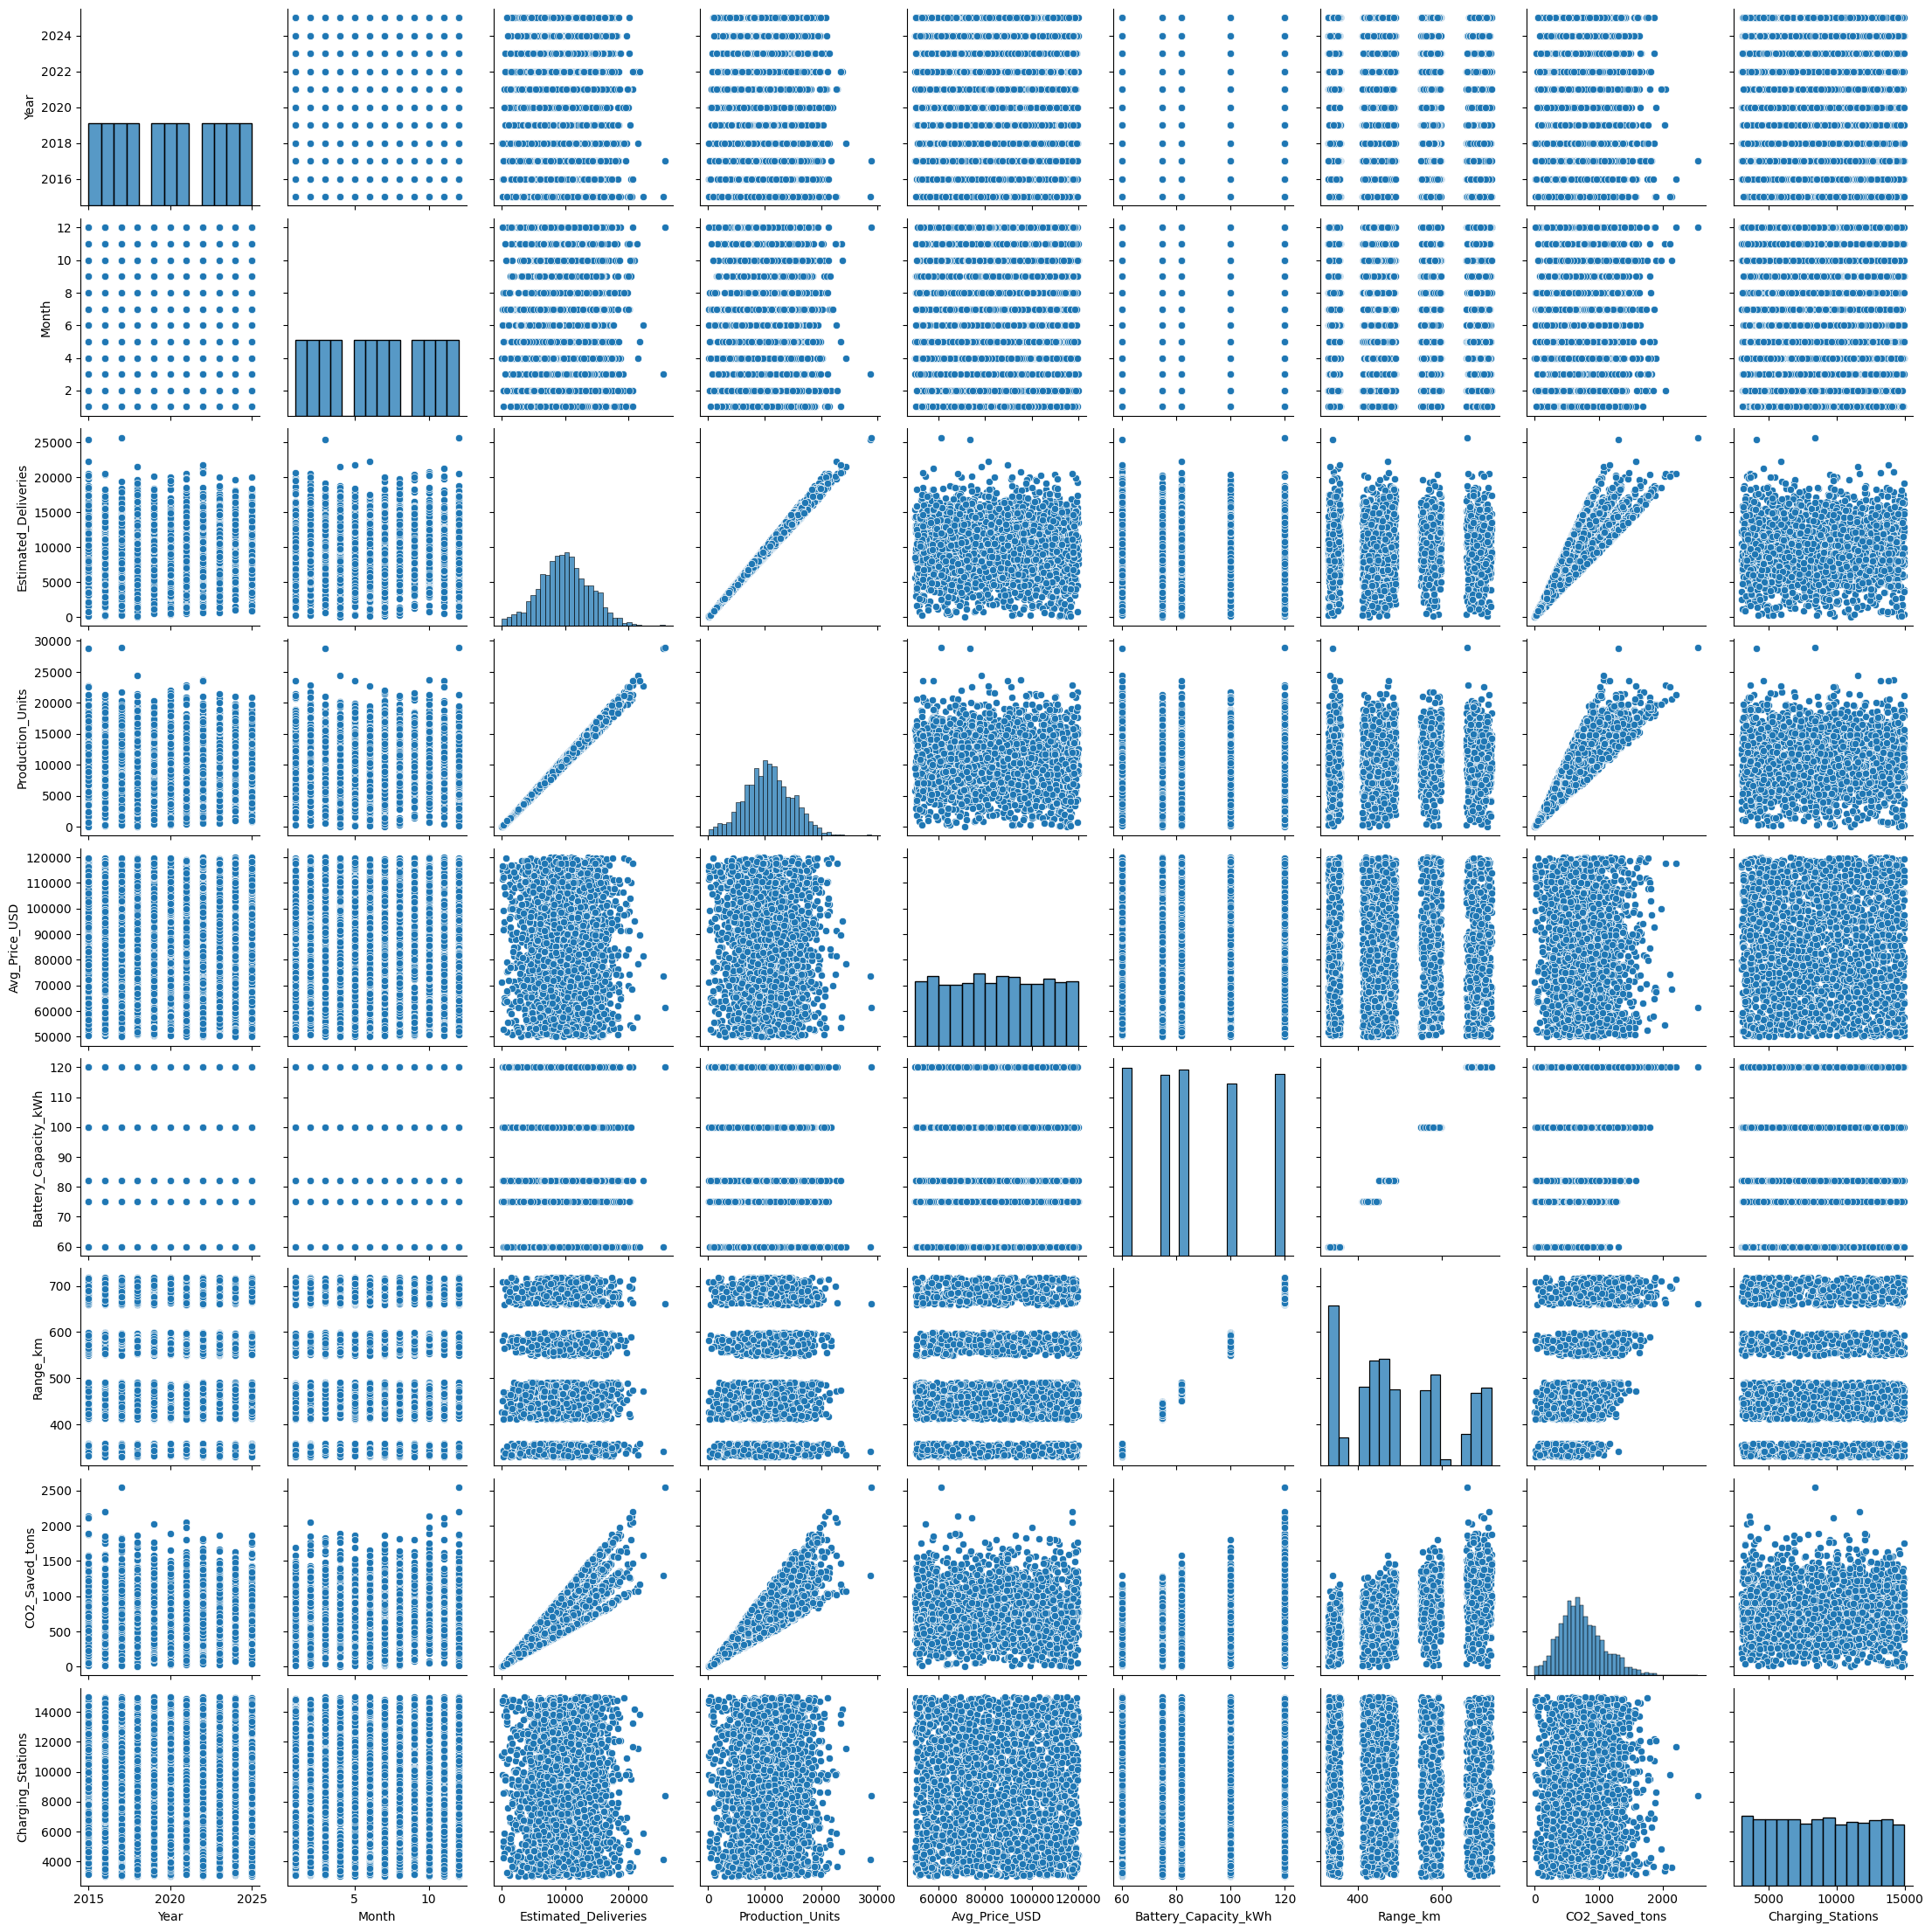

In [12]:
sns.pairplot(
    df.select_dtypes(include=np.number)
)

plt.show()

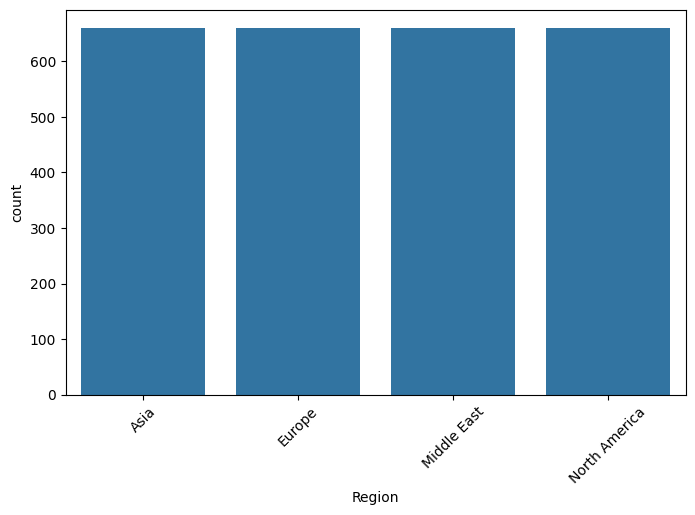

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x="Region",data=df)
plt.xticks(rotation=45)
plt.show()

In [14]:
df["Date"] = pd.to_datetime(
    dict(
        year=df.Year,
        month=df.Month,
        day=1
    )
)

In [15]:
df["Quarter"] = df["Date"].dt.quarter

In [16]:
df["Vehicle_Age"] = 2025 - df["Year"]

In [17]:
df["Price_per_km"] = (
    df["Avg_Price_USD"] /
    df["Range_km"]
)

In [18]:
df["Production_Efficiency"] = (
    df["Estimated_Deliveries"] /
    df["Production_Units"]
)

In [19]:
df["Charging_Ratio"] = (
    df["Charging_Stations"] /
    df["Estimated_Deliveries"]
)

In [20]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Vehicle_Age,Price_per_km,Production_Efficiency,Charging_Ratio
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,2,2,131.923679,0.984600,0.691772
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,1,10,142.022032,0.911864,2.012115
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,1,6,245.598583,0.915334,1.672928
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,1,4,125.414199,0.896594,1.423799
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,4,9,173.747020,0.914087,0.704865


In [21]:
encoder = LabelEncoder()
df["Region"] = encoder.fit_transform(df["Region"])
df["Model"] = encoder.fit_transform(df["Model"])
df["Source_Type"] = encoder.fit_transform(df["Source_Type"])

In [22]:
y = df["Avg_Price_USD"]

In [23]:
X = df.drop(
    [
        "Avg_Price_USD",
        "Date"
    ],
    axis=1
)

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
lr = LinearRegression()
lr.fit(X_train,y_train)
pred_lr = lr.predict(X_test)

In [27]:
print("MAE:",mean_absolute_error(y_test,pred_lr))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred_lr)))
print("R2:",r2_score(y_test,pred_lr))

MAE: 4988.729519892865
RMSE: 6136.40647173232
R2: 0.9001479377194355


In [28]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)
pred_dt = dt.predict(X_test)

In [29]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
pred_rf = rf.predict(X_test)

In [30]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train,y_train)
pred_gb = gb.predict(X_test)

In [31]:
params = {"n_estimators":[100,200,300],"max_depth":[5,10,15],"min_samples_split":[2,5]}

In [32]:
grid = GridSearchCV(RandomForestRegressor(),
                    params,
                    cv=5,
                    scoring="r2",
                    n_jobs=-1
                   )
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15], 'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [33]:
best_rf = grid.best_estimator_

In [34]:
models = {"Linear":lr, "Decision Tree":dt, "Random Forest":rf,"Gradient Boosting":gb,"Best RF":best_rf
}

In [35]:
results = []
for name,model in models.items():
    pred = model.predict(X_test)
    results.append([
        name,
        mean_absolute_error(y_test,pred),
        np.sqrt(mean_squared_error(y_test,pred)),
        r2_score(y_test,pred)

    ])

In [36]:
results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

results.sort_values("R2",ascending=False)

,Model,MAE,RMSE,R2
4,Best RF,637.609145,872.074184,0.997983
2,Random Forest,658.631064,887.876038,0.997910
1,Decision Tree,1192.744470,1594.462017,0.993258
3,Gradient Boosting,1216.614503,1598.813275,0.993222
0,Linear,4988.729520,6136.406472,0.900148


In [37]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":best_rf.feature_importances_

})

In [38]:
importance = importance.sort_values(
    by="Importance",
    ascending=False

)

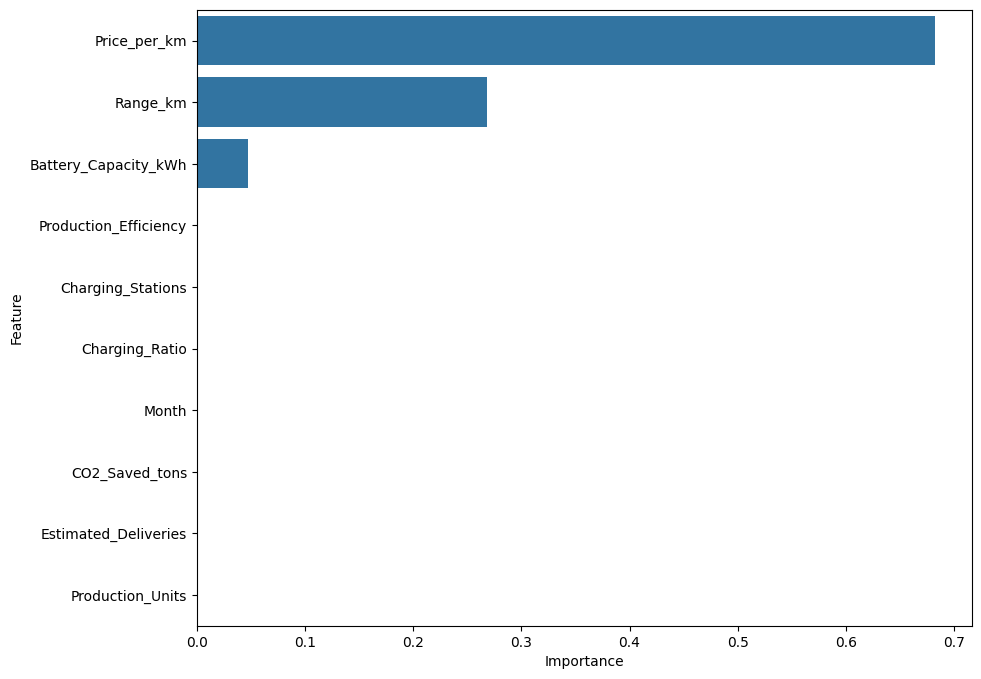

In [39]:
plt.figure(figsize=(10,8))
sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)
plt.show()

In [40]:
monthly = df.groupby("Date")["Estimated_Deliveries"].sum()

In [41]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(monthly,order=(5,1,0))
fit = model.fit()

C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [42]:
forecast = fit.forecast(12)

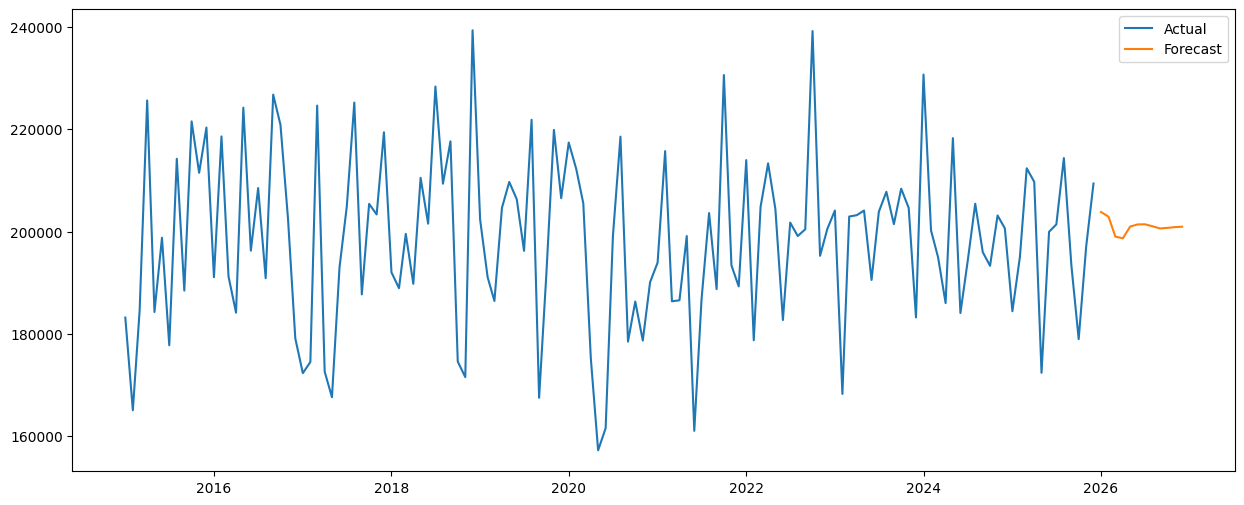

In [43]:
plt.figure(figsize=(15,6))
plt.plot(monthly,label="Actual")
plt.plot(forecast,label="Forecast")
plt.legend()
plt.show()

In [44]:
joblib.dump(best_rf,"Tesla_Price_Model.pkl")

['Tesla_Price_Model.pkl']

In [45]:
model = joblib.load("Tesla_Price_Model.pkl")

In [47]:
comparison = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": model.predict(X_test[:5])
})

print(comparison)

      Actual      Predicted
0   77791.05   78515.458286
1  100029.16  102162.341375
2   68450.11   68647.590125
3   86288.53   87316.706550
4  109940.95  110377.259452
